# Discriminant Analysis for Alzheimer's Disease

This notebook mirrors the structure of INFO381A_LR.ipynb, but focuses on linear discriminant analysis (LDA), feature separation, and statistical interpretation.

Imports

In [1]:
import json
import os
from pathlib import Path

import kagglehub as kh
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2, f_oneway
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')

OUT_DIR = Path('outputs')
OUT_DIR.mkdir(parents=True, exist_ok=True)

REDUCED_EXCLUDE_COLS = [
    'MMSE', 'ADL', 'FunctionalAssessment',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation', 'PersonalityChanges',
    'DifficultyCompletingTasks', 'Forgetfulness',
]

c:\Users\jonas\Projects\uib\381\Alzheimer-s-Analytics\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load dataset

In [2]:
path = kh.dataset_download('rabieelkharoua/alzheimers-disease-dataset')
print('Path to dataset files:', path)

files = os.listdir(path)
print('Files in directory:', files)

csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)

DATA_PATH = Path(csv_path)

df = pd.read_csv(csv_path)
print('Shape:', df.shape)
df.head()

Path to dataset files: C:\Users\jonas\.cache\kagglehub\datasets\rabieelkharoua\alzheimers-disease-dataset\versions\1
Files in directory: ['alzheimers_disease_data.csv']
Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


Basic overview

In [3]:
df.info()
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64  
 14  Dep

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


Check for missing values

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

Series([], dtype: int64)

Class distribution

Diagnosis
0    1389
1     760
Name: count, dtype: int64
Diagnosis
0    0.646347
1    0.353653
Name: proportion, dtype: float64


C:\Users\jonas\AppData\Local\Temp\ipykernel_9536\3278711309.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Diagnosis', data=df, palette='magma')


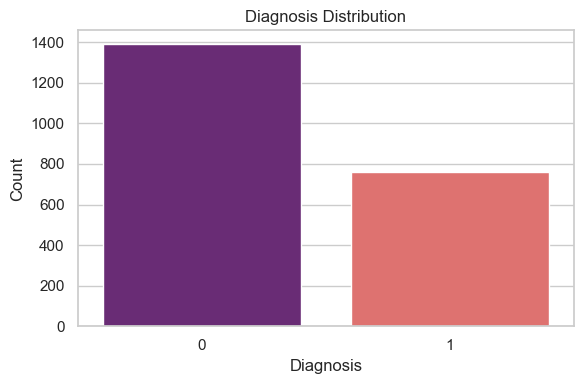

In [5]:
print(df['Diagnosis'].value_counts())
print(df['Diagnosis'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df, palette='magma')
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Drop irrelevant columns and define feature groups

In [ ]:
df = df.drop(columns=['PatientID', 'DoctorInCharge'], errors='ignore')

target_col = 'Diagnosis'
binary_cols = [
    'Gender', 'Smoking', 'FamilyHistoryAlzheimers',
    'CardiovascularDisease', 'Diabetes', 'Depression',
    'HeadInjury', 'Hypertension',
    'MemoryComplaints', 'BehavioralProblems',
    'Confusion', 'Disorientation',
    'PersonalityChanges', 'DifficultyCompletingTasks',
    'Forgetfulness'
]
# Variables need dummy encoding
categorical_cols = ['Ethnicity', 'EducationLevel']

# Remaining treated as numeric
numeric_cols = [col for col in df.columns if col not in binary_cols + categorical_cols + [target_col]]

print('Numeric:', numeric_cols)
print('Binary:', binary_cols)
print('Categorical:', categorical_cols)

X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()
# Convert categorical variables into dummy
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

FULL_FEATURES = X.columns.tolist()
REDUCED_FEATURES = X.drop(columns=REDUCED_EXCLUDE_COLS, errors='ignore').columns.tolist()

analysis_df = pd.concat([X, y.rename(target_col)], axis=1)

print(f'Full feature count: {len(FULL_FEATURES)}')
print(f'Reduced feature count: {len(REDUCED_FEATURES)}')

Numeric: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Binary: ['Gender', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']
Categorical: ['Ethnicity', 'EducationLevel']
Full feature count: 36
Reduced feature count: 26


Correlation matrix

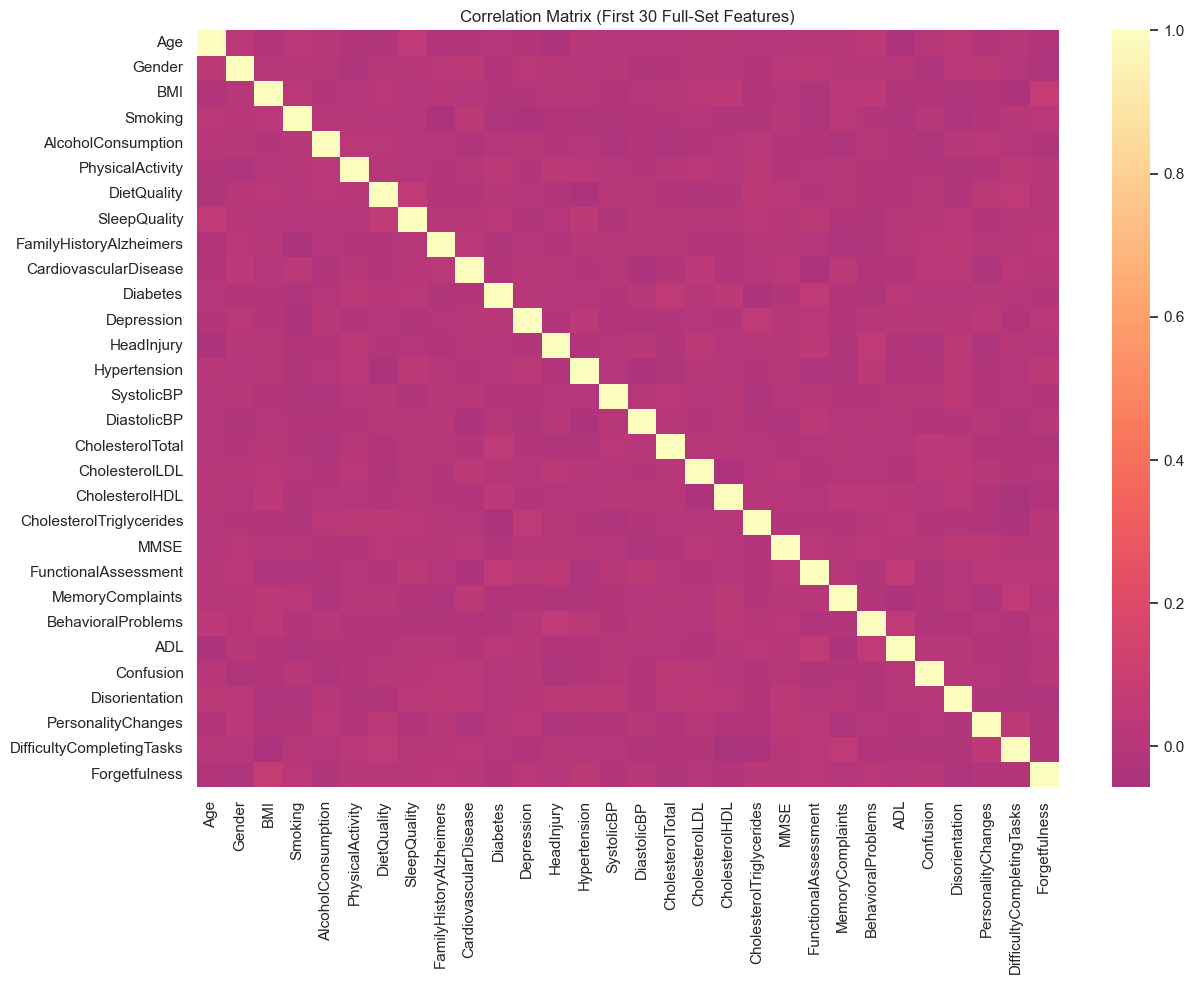

In [7]:
plot_cols = [col for col in FULL_FEATURES if col in analysis_df.columns][:30]
plt.figure(figsize=(13, 10))
sns.heatmap(analysis_df[plot_cols].corr(), cmap='magma', center=0)
plt.title('Correlation Matrix (First 30 Full-Set Features)')
plt.tight_layout()
plt.show()

Prepare analysis helpers

In [ ]:
# Median imputation + scaling + LDA classifier
def make_pipeline():
    return Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('lda', LinearDiscriminantAnalysis()),
        ]
    )

# Preprocessing before computing scatter matrices
def compute_wilks_lambda(X: pd.DataFrame, y: pd.Series):
    prep = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]
    )
    x_mat = prep.fit_transform(X)
    y_arr = np.asarray(y)
    classes = np.unique(y_arr)

    n_samples, n_features = x_mat.shape
    n_groups = len(classes)

    grand_mean = np.mean(x_mat, axis=0)
    centered = x_mat - grand_mean
    total_sscp = centered.T @ centered

    within_sscp = np.zeros_like(total_sscp)
    for cls in classes:
        x_group = x_mat[y_arr == cls]
        group_mean = np.mean(x_group, axis=0)
        group_centered = x_group - group_mean
        within_sscp += group_centered.T @ group_centered

    log_lambda = None
    ridge_used = None
    for ridge in (1e-10, 1e-8, 1e-6, 1e-4, 1e-2):
        identity = np.eye(n_features)
        sign_w, logdet_w = np.linalg.slogdet(within_sscp + ridge * identity)
        sign_t, logdet_t = np.linalg.slogdet(total_sscp + ridge * identity)
        if sign_w > 0 and sign_t > 0:
            log_lambda = float(logdet_w - logdet_t)
            ridge_used = ridge
            break

    if log_lambda is None:
        return {
            'wilks_lambda': None,
            'log_wilks_lambda': None,
            'chi_square_approx': None,
            'df': int(n_features * (n_groups - 1)),
            'p_value_approx': None,
            'ridge_used': None,
        }

    wilks_lambda = float(np.exp(log_lambda))
    df = int(n_features * (n_groups - 1))

    bartlett_factor = (n_samples - 1) - (n_features + n_groups) / 2
    chi_square = float(max(0.0, -bartlett_factor * log_lambda))
    p_value = float(1 - chi2.cdf(chi_square, df)) if df > 0 else None

    return {
        'wilks_lambda': wilks_lambda,
        'log_wilks_lambda': log_lambda,
        'chi_square_approx': chi_square,
        'df': df,
        'p_value_approx': p_value,
        'ridge_used': ridge_used,
    }

# Generate cross-validated predictions for a fair performance estimate
def run_lda_task(df: pd.DataFrame, target: str, features: list[str], task_name: str):
    available = [col for col in features if col in df.columns]
    data = df[available + [target]].dropna(subset=[target]).copy()

    X = data[available]
    y = data[target].astype(int)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    pipeline = make_pipeline()
    y_pred = cross_val_predict(pipeline, X, y, cv=cv)
    y_proba = cross_val_predict(pipeline, X, y, cv=cv, method='predict_proba')

    accuracy = accuracy_score(y, y_pred)
    macro_f1 = f1_score(y, y_pred, average='macro')
    roc_curve_data = None
    if y.nunique() == 2:
        roc_auc = roc_auc_score(y, y_proba[:, 1])
        fpr, tpr, _ = roc_curve(y, y_proba[:, 1])
        roc_curve_data = {
            'fpr': fpr.tolist(),
            'tpr': tpr.tolist(),
            'auc': float(roc_auc),
        }
    else:
        roc_auc = roc_auc_score(y, y_proba, multi_class='ovr', average='macro')
    wilks_stats = compute_wilks_lambda(X, y)

    fitted = make_pipeline()
    fitted.fit(X, y)
    lda = fitted.named_steps['lda']

    explained_var = None
    cumsum_explained_var = None
    if hasattr(lda, 'explained_variance_ratio_'):
        explained_var = lda.explained_variance_ratio_.tolist()
        cumsum_explained_var = float(np.cumsum(lda.explained_variance_ratio_)[-1]) if len(lda.explained_variance_ratio_) > 0 else 0.0

    if y.nunique() == 2 and hasattr(lda, 'coef_'):
        feature_strength = np.abs(lda.coef_.ravel())
    else:
        feature_strength = np.mean(np.abs(lda.scalings_), axis=1)

    importance = (
        pd.DataFrame({'feature': available, 'importance_abs': feature_strength})
        .sort_values('importance_abs', ascending=False)
        .reset_index(drop=True)
    )

    importance_file = OUT_DIR / f'lda_feature_importance_{task_name}.csv'
    importance.to_csv(importance_file, index=False)

    return {
        'task': task_name,
        'target': target,
        'n_samples': int(len(data)),
        'n_features': int(len(available)),
        'random_state': 42,
        'cv_accuracy': float(accuracy),
        'cv_macro_f1': float(macro_f1),
        'cv_roc_auc': float(roc_auc),
        'roc_curve': roc_curve_data,
        'explained_variance_ratio': explained_var,
        'total_explained_variance': cumsum_explained_var,
        'wilks_lambda': wilks_stats,
        'top_features': importance.head(10).to_dict(orient='records'),
        'importance_file': str(importance_file),
    }

def plot_top_importance(result: dict, title: str, top_n: int = 10):
    importance = pd.read_csv(result['importance_file']).head(top_n).iloc[::-1]
    plt.figure(figsize=(10, 6))
    plt.barh(importance['feature'], importance['importance_abs'], color='#3b6fb6')
    plt.title(title)
    plt.xlabel('Absolute discriminant strength')
    plt.tight_layout()
    plt.show()


def plot_roc_curve_comparison(full_result: dict, reduced_result: dict):
    plt.figure(figsize=(8, 6))
    for result, color in ((full_result, '#2a9d8f'), (reduced_result, '#e76f51')):
        roc_data = result.get('roc_curve')
        if not roc_data:
            continue
        plt.plot(
            roc_data['fpr'],
            roc_data['tpr'],
            color=color,
            linewidth=2.5,
            label=f"{result['task']} (AUC = {roc_data['auc']:.3f})",
        )

    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5, label='Chance')
    plt.title('ROC Curves: Full vs Reduced LDA Models')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

Diagnosis (Full Feature Set)

In [9]:
full_result = run_lda_task(
    df=analysis_df,
    target='Diagnosis',
    features=FULL_FEATURES,
    task_name='diagnosis_full_feature_set',
)

full_result

{'task': 'diagnosis_full_feature_set',
 'target': 'Diagnosis',
 'n_samples': 2149,
 'n_features': 36,
 'random_state': 42,
 'cv_accuracy': 0.8352722196370405,
 'cv_macro_f1': 0.8166424679246156,
 'cv_roc_auc': 0.8965944829676784,
 'roc_curve': {'fpr': [0.0,
   0.0,
   0.0,
   0.0007199424046076314,
   0.0007199424046076314,
   0.0014398848092152627,
   0.0014398848092152627,
   0.0021598272138228943,
   0.0021598272138228943,
   0.0028797696184305254,
   0.0028797696184305254,
   0.004319654427645789,
   0.004319654427645789,
   0.005039596832253419,
   0.005039596832253419,
   0.0064794816414686825,
   0.0064794816414686825,
   0.007199424046076314,
   0.007199424046076314,
   0.007919366450683946,
   0.007919366450683946,
   0.008639308855291577,
   0.008639308855291577,
   0.010079193664506839,
   0.010079193664506839,
   0.01079913606911447,
   0.01079913606911447,
   0.012958963282937365,
   0.012958963282937365,
   0.013678905687544997,
   0.013678905687544997,
   0.0143988480921

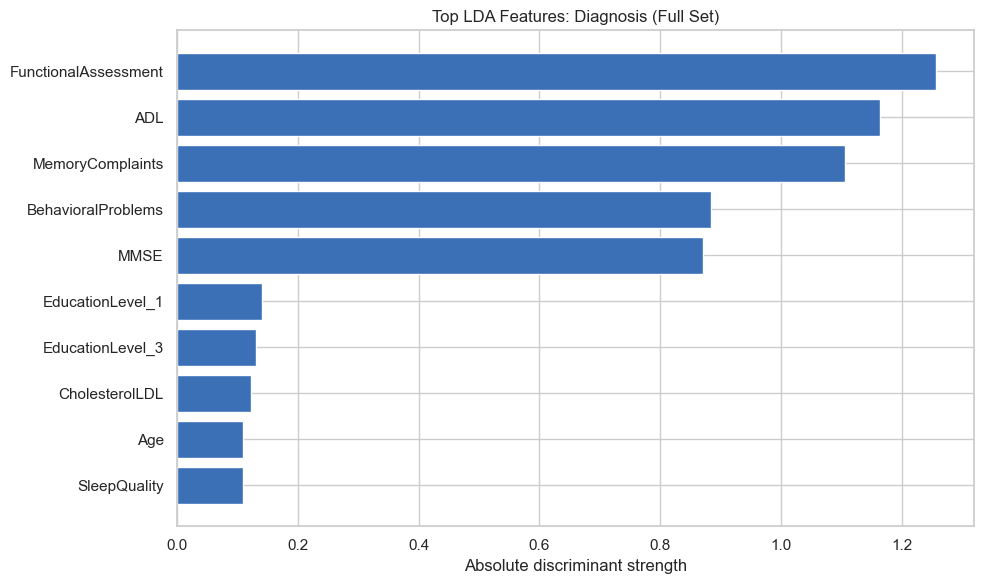

In [10]:
plot_top_importance(full_result, 'Top LDA Features: Diagnosis (Full Set)')

Diagnosis (Reduced Feature Set)

In [11]:
reduced_result = run_lda_task(
    df=analysis_df,
    target='Diagnosis',
    features=REDUCED_FEATURES,
    task_name='diagnosis_reduced_feature_set',
)

reduced_result

{'task': 'diagnosis_reduced_feature_set',
 'target': 'Diagnosis',
 'n_samples': 2149,
 'n_features': 26,
 'random_state': 42,
 'cv_accuracy': 0.6384364820846905,
 'cv_macro_f1': 0.41066245956577213,
 'cv_roc_auc': 0.5297582509188739,
 'roc_curve': {'fpr': [0.0,
   0.0007199424046076314,
   0.0014398848092152627,
   0.0014398848092152627,
   0.0021598272138228943,
   0.0021598272138228943,
   0.0064794816414686825,
   0.0064794816414686825,
   0.009359251259899209,
   0.009359251259899209,
   0.010079193664506839,
   0.010079193664506839,
   0.012239020878329733,
   0.012239020878329733,
   0.012958963282937365,
   0.012958963282937365,
   0.01511879049676026,
   0.01511879049676026,
   0.01655867530597552,
   0.01655867530597552,
   0.017278617710583154,
   0.017278617710583154,
   0.017998560115190784,
   0.017998560115190784,
   0.02159827213822894,
   0.02159827213822894,
   0.022318214542836574,
   0.022318214542836574,
   0.023038156947444204,
   0.023038156947444204,
   0.0251979

Reduced-Set Feature Importance

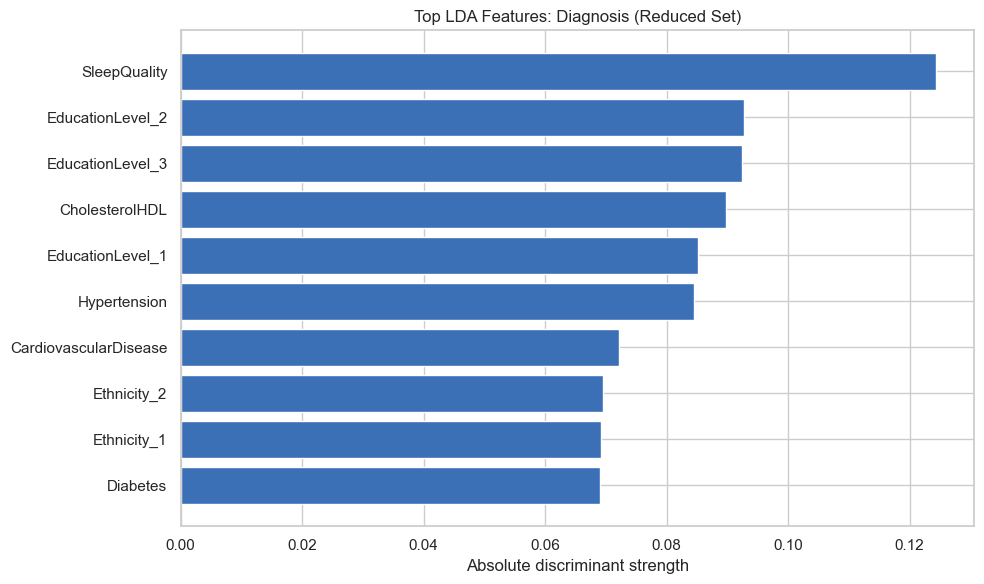

In [12]:
plot_top_importance(reduced_result, 'Top LDA Features: Diagnosis (Reduced Set)')

Metric Delta (Full vs Reduced)

In [13]:
metric_delta = {
    'accuracy_delta_full_minus_reduced': full_result['cv_accuracy'] - reduced_result['cv_accuracy'],
    'macro_f1_delta_full_minus_reduced': full_result['cv_macro_f1'] - reduced_result['cv_macro_f1'],
    'roc_auc_delta_full_minus_reduced': full_result['cv_roc_auc'] - reduced_result['cv_roc_auc'],
}
metric_delta

{'accuracy_delta_full_minus_reduced': 0.19683573755234995,
 'macro_f1_delta_full_minus_reduced': 0.40598000835884346,
 'roc_auc_delta_full_minus_reduced': 0.36683623204880456}

Summary Table

In [14]:
results_df = pd.DataFrame([
    {
        'task': full_result['task'],
        'target': full_result['target'],
        'n_samples': full_result['n_samples'],
        'n_features': full_result['n_features'],
        'cv_accuracy': full_result['cv_accuracy'],
        'cv_macro_f1': full_result['cv_macro_f1'],
        'cv_roc_auc': full_result['cv_roc_auc'],
        'wilks_lambda': full_result['wilks_lambda']['wilks_lambda'],
        'wilks_p_value': full_result['wilks_lambda']['p_value_approx'],
    },
    {
        'task': reduced_result['task'],
        'target': reduced_result['target'],
        'n_samples': reduced_result['n_samples'],
        'n_features': reduced_result['n_features'],
        'cv_accuracy': reduced_result['cv_accuracy'],
        'cv_macro_f1': reduced_result['cv_macro_f1'],
        'cv_roc_auc': reduced_result['cv_roc_auc'],
        'wilks_lambda': reduced_result['wilks_lambda']['wilks_lambda'],
        'wilks_p_value': reduced_result['wilks_lambda']['p_value_approx'],
    },
]).round(4)

display(results_df)

,task,target,n_samples,n_features,cv_accuracy,cv_macro_f1,cv_roc_auc,wilks_lambda,wilks_p_value
0,diagnosis_full_feature_set,Diagnosis,2149,36,0.8353,0.8166,0.8966,0.5619,0.0000
1,diagnosis_reduced_feature_set,Diagnosis,2149,26,0.6384,0.4107,0.5298,0.9816,0.0431


Performance Comparison

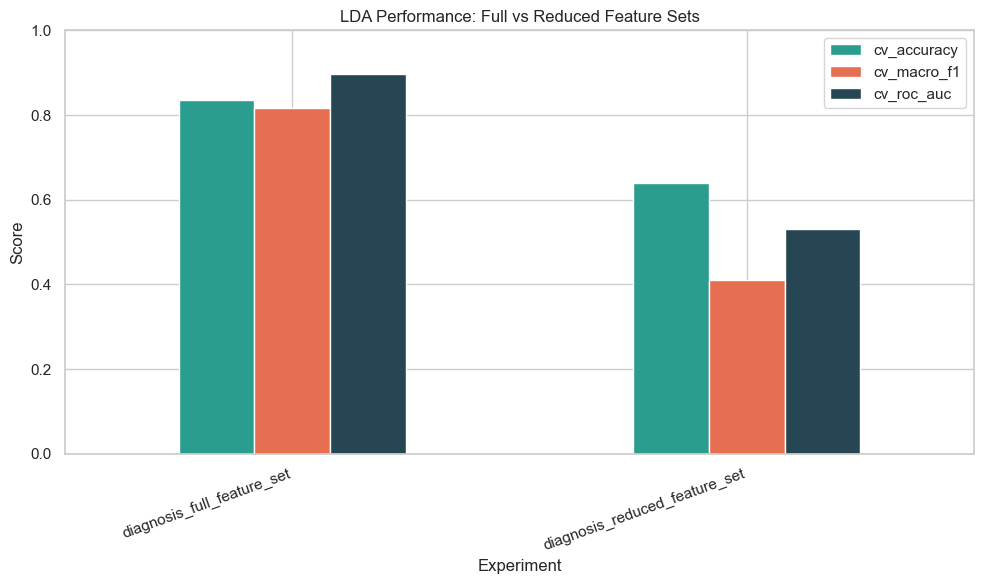

In [15]:
plot_df = results_df[['task', 'cv_accuracy', 'cv_macro_f1', 'cv_roc_auc']].set_index('task')

ax = plot_df.plot(kind='bar', figsize=(10, 6), color=['#2a9d8f', '#e76f51', '#264653'])
ax.set_title('LDA Performance: Full vs Reduced Feature Sets')
ax.set_ylabel('Score')
ax.set_xlabel('Experiment')
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

ROC Curve Comparison

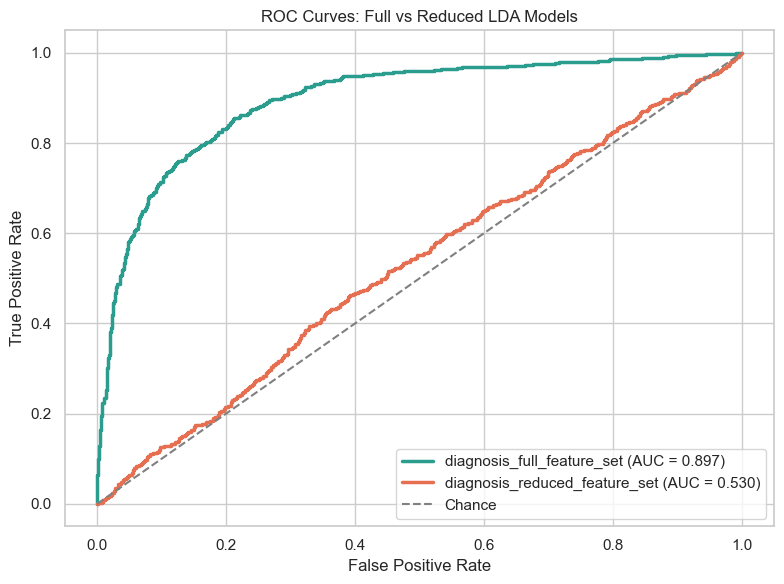

In [16]:
plot_roc_curve_comparison(full_result, reduced_result)

Exctract results

In [17]:
report = {
    'diagnosis_full_feature_set': full_result,
    'diagnosis_reduced_feature_set': reduced_result,
    'feature_set_definition': {
        'full_feature_count': len(FULL_FEATURES),
        'reduced_feature_count': len(REDUCED_FEATURES),
        'reduced_excluded_columns': REDUCED_EXCLUDE_COLS,
    },
}

report_path = OUT_DIR / 'discriminant_analysis_report.json'
report_path.write_text(json.dumps(report, indent=2), encoding='utf-8')
print(f'Wrote: {report_path}')

Wrote: outputs\discriminant_analysis_report.json


Conclusion

The LDA results summarize how strongly symptoms, clinical measurements, and demographic variables separate diagnosis, gender, and education groups in this dataset.